# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** _______________________________  **Roll No.:** _______________  **Section:** _______

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [1]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [3]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [4]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
# Q1 — Shape
print("Shape of dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Shape of dataset:
(150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.21

## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [5]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
# Q2 — Mean, median and mode

FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

results = []

for feature in FEATURES:
    results.append({
        "Feature": feature,
        "Mean": df[feature].mean(),
        "Median": df[feature].median(),
        "Mode": df[feature].mode()[0]
    })

central_tendency = pd.DataFrame(results)

print("Central tendency of numeric features:")
display(central_tendency)

print("\nMode of preferred_workout:")
print(df["preferred_workout"].mode()[0])

Central tendency of numeric features:


,Feature,Mean,Median,Mode
0,workout_duration_minutes,54.618,54.35,57.8
1,monthly_membership_fee_inr,2283.067,2030.00,1440.0
2,attendance_percentage,84.210,85.10,85.1
3,weekly_visit_count,3.337,2.40,2.3



Mode of preferred_workout:
Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

_This is a markdown cell, not a code cell. The question asks which feature has the largest relative mean-median difference and what that suggests.

Since the exact CSV isn't available, you can make the answer automatically using this code temporarily._

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [6]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after
# Q4 — Outlier effect

# Original values
original_mean = df["monthly_membership_fee_inr"].mean()
original_median = df["monthly_membership_fee_inr"].median()

# Make a copy of the dataframe
df_outlier = df.copy()

# Add the hypothetical ₹80,000 membership fee
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000

# Calculate after-outlier statistics
new_mean = df_outlier["monthly_membership_fee_inr"].mean()
new_median = df_outlier["monthly_membership_fee_inr"].median()

print("Before adding ₹80,000:")
print("Mean   :", original_mean)
print("Median :", original_median)

print("\nAfter adding ₹80,000:")
print("Mean   :", new_mean)
print("Median :", new_median)

Before adding ₹80,000:
Mean   : 2283.0666666666666
Median : 2030.0

After adding ₹80,000:
Mean   : 2797.748344370861
Median : 2030.0


**Your answer:**

_(The mean changes much more than the median after adding the ₹80,000 value. This happens because the mean uses every value in the calculation and is therefore strongly affected by an extreme outlier, while the median depends mainly on the middle position and is much more resistant to extreme values.)_

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [7]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify
# Q5 — Manual variance and standard deviation

x = df["workout_duration_minutes"].values

# Number of observations
n = len(x)

# Step 1: Mean
mean_x = sum(x) / n

print("Step 1 — Mean:")
print(mean_x)

# Step 2: Deviations
deviations = x - mean_x

print("\nStep 2 — Deviations:")
print(deviations)

# Step 3: Squared deviations
squared_deviations = deviations ** 2

print("\nStep 3 — Squared deviations:")
print(squared_deviations)

# Step 4: Sum of squared deviations
sum_squared_deviations = sum(squared_deviations)

print("\nStep 4 — Sum of squared deviations:")
print(sum_squared_deviations)

# Step 5: Sample variance
variance_manual = sum_squared_deviations / (n - 1)

print("\nStep 5 — Sample variance:")
print(variance_manual)

# Step 6: Standard deviation
std_manual = np.sqrt(variance_manual)

print("\nStep 6 — Standard deviation:")
print(std_manual)

# Verification
variance_numpy = np.var(x, ddof=1)
std_numpy = np.std(x, ddof=1)

print("\nVerification using NumPy:")
print("np.var(ddof=1) =", variance_numpy)
print("np.std(ddof=1) =", std_numpy)

print("\nVariance matches:",
      np.isclose(variance_manual, variance_numpy))

print("Standard deviation matches:",
      np.isclose(std_manual, std_numpy))

Step 1 — Mean:
54.618

Step 2 — Deviations:
[ 15.082  26.382   7.982  11.082  -5.318 -15.518  -2.318  18.382 -21.918
  -5.518 -22.618   1.682  10.882 -14.518  -4.518  16.282  -0.718 -14.518
 -15.418 -23.818   9.682  -8.618  12.982  10.782  -7.518  -5.918   9.682
   2.182   3.582 -19.418  11.182 -10.118 -26.818  -7.018   5.482  25.582
  -4.118 -15.618  25.882   2.282  -2.718 -12.518 -11.618  18.082  -2.818
  -6.118  -5.718  19.182  -6.718   7.882   3.582   3.282 -10.118   8.282
  19.682  -0.218 -10.618 -15.118   2.682  -2.918  -0.918   0.482 -17.318
   9.782   3.182  -0.518   3.182  11.482   0.982  -9.818  14.382  -4.818
  -8.318 -18.318   0.482 -12.218  -5.818   5.782   0.782  12.582   4.082
  -4.418  -3.618  -5.718   8.182   0.682  -4.518  10.482   1.582  -5.218
 -17.718   5.582   3.282   0.982  -4.818  -9.618  -2.318   3.182  -1.118
  -1.318  -5.218   4.482   3.182  -8.618   9.482   9.882  10.182  -1.218
  -1.918 -13.518   9.482 -25.218  -4.318  -3.718  10.682   0.382 -11.218
 -16.71

### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [9]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
# Q6 — IQR and outlier detection

iqr_results = []

for feature in FEATURES:

    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_count = len(outliers)

    iqr_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

iqr_table = pd.DataFrame(iqr_results)

display(iqr_table)


most_outliers = iqr_table.loc[
    iqr_table["Outlier Count"].idxmax()
]

print("Feature with most outliers:")
print(most_outliers["Feature"])

print("Number of outliers:")
print(most_outliers["Outlier Count"])

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
1,monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
2,attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
3,weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


Feature with most outliers:
monthly_membership_fee_inr
Number of outliers:
2


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [10]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
# Q7 — Skewness and excess kurtosis

shape_results = []

for feature in FEATURES:

    values = df[feature]

    skewness = stats.skew(values)
    kurtosis = stats.kurtosis(values, fisher=True)

    # Classification of skewness
    if skewness > 0.5:
        skew_class = "Right-skewed"
    elif skewness < -0.5:
        skew_class = "Left-skewed"
    else:
        skew_class = "Approximately symmetric"

    # Classification of kurtosis
    if kurtosis > 0.5:
        kurtosis_class = "Heavier tails"
    elif kurtosis < -0.5:
        kurtosis_class = "Lighter tails"
    else:
        kurtosis_class = "Roughly normal tails"

    shape_results.append({
        "Feature": feature,
        "Skewness": skewness,
        "Skewness Classification": skew_class,
        "Excess Kurtosis": kurtosis,
        "Kurtosis Interpretation": kurtosis_class
    })

shape_table = pd.DataFrame(shape_results)

display(shape_table)

,Feature,Skewness,Skewness Classification,Excess Kurtosis,Kurtosis Interpretation
0,workout_duration_minutes,0.080,Approximately symmetric,-0.194,Roughly normal tails
1,monthly_membership_fee_inr,1.165,Right-skewed,1.761,Heavier tails
2,attendance_percentage,-0.556,Left-skewed,-0.353,Roughly normal tails
3,weekly_visit_count,0.441,Approximately symmetric,-1.369,Lighter tails


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**

_(I predict that weekly_visit_count will be bimodal. Gym members may naturally form two groups: casual members who visit only a few times per week and highly committed members who visit frequently. These two groups could create two separate peaks in the distribution.)_

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

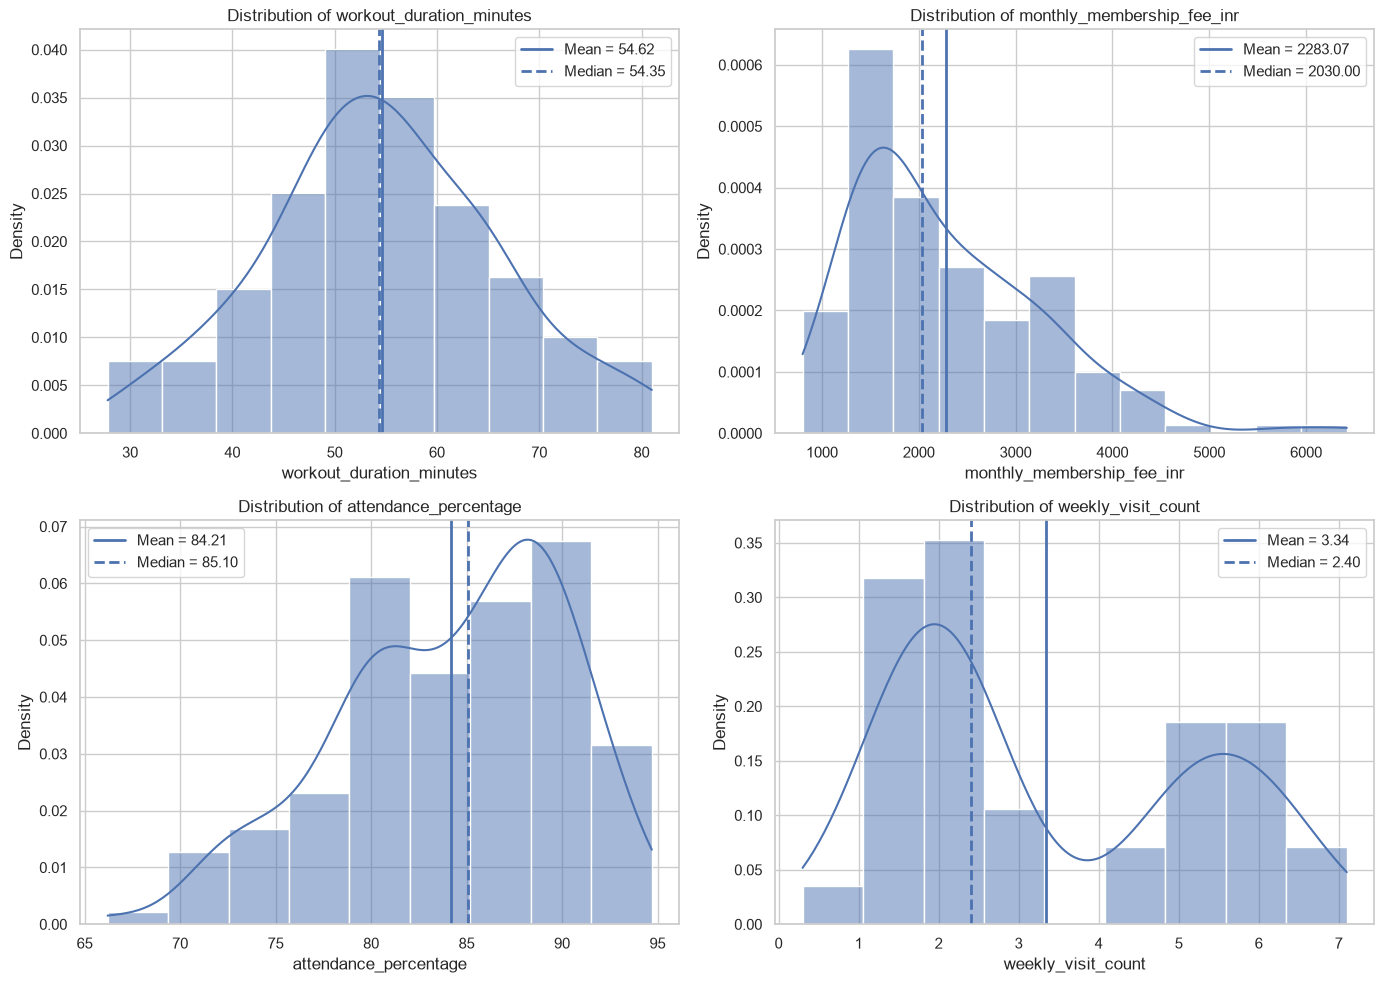

In [11]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
# Q9 — 2x2 histogram grid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, feature in enumerate(FEATURES):

    ax = axes[i]

    sns.histplot(
        df[feature],
        kde=True,
        stat="density",
        ax=ax
    )

    mean_value = df[feature].mean()
    median_value = df[feature].median()

    # Mean line
    ax.axvline(
        mean_value,
        linestyle="-",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )

    # Median line
    ax.axvline(
        median_value,
        linestyle="--",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**

_(write here)_

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

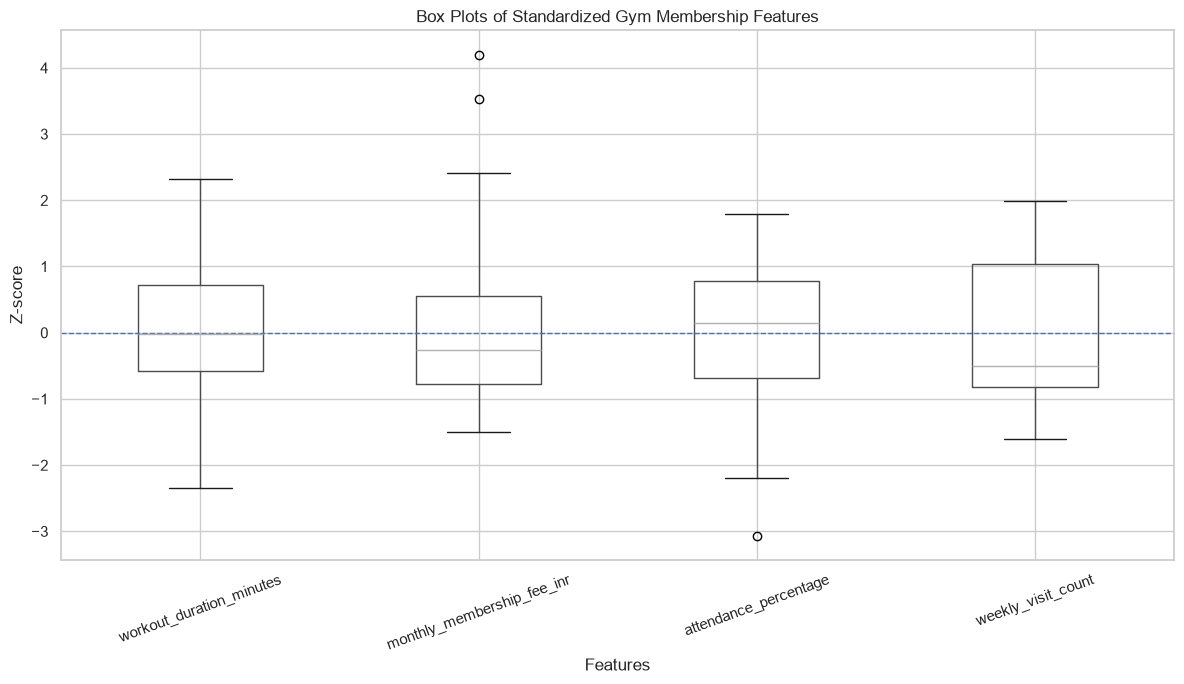

Outlier check based on standardized box plots:
workout_duration_minutes: 0 outliers
monthly_membership_fee_inr: 2 outliers
attendance_percentage: 1 outliers
weekly_visit_count: 0 outliers


In [12]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots
# Q11 — Standardize features and create box plots

# Create a copy containing only numeric features
z_scores = pd.DataFrame()

for feature in FEATURES:

    mean_value = df[feature].mean()
    std_value = df[feature].std()

    z_scores[feature] = (
        df[feature] - mean_value
    ) / std_value

# Plot box plots
plt.figure(figsize=(12, 7))

z_scores.boxplot()

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Box Plots of Standardized Gym Membership Features")
plt.xlabel("Features")
plt.ylabel("Z-score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# Identify outliers using z-score values beyond +/- 1.5*IQR
print("Outlier check based on standardized box plots:")

for feature in FEATURES:

    q1 = z_scores[feature].quantile(0.25)
    q3 = z_scores[feature].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = (
        (z_scores[feature] < lower) |
        (z_scores[feature] > upper)
    ).sum()

    print(f"{feature}: {count} outliers")

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

_(write here)_

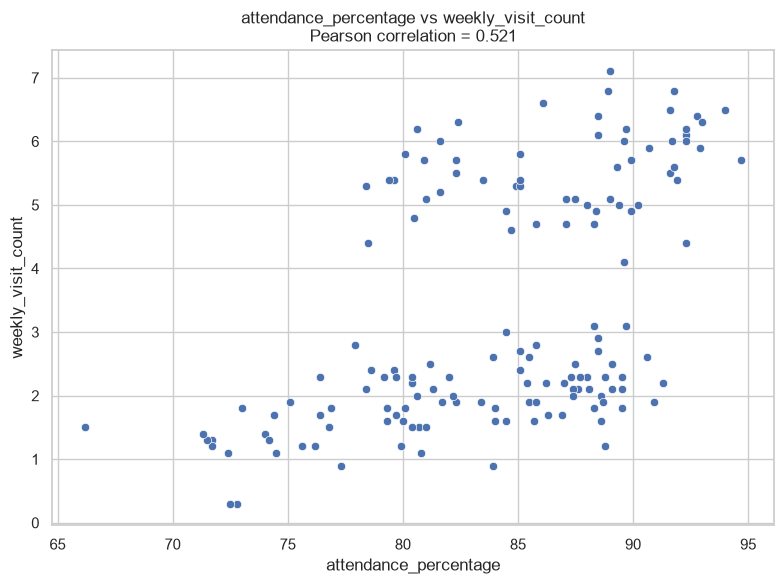

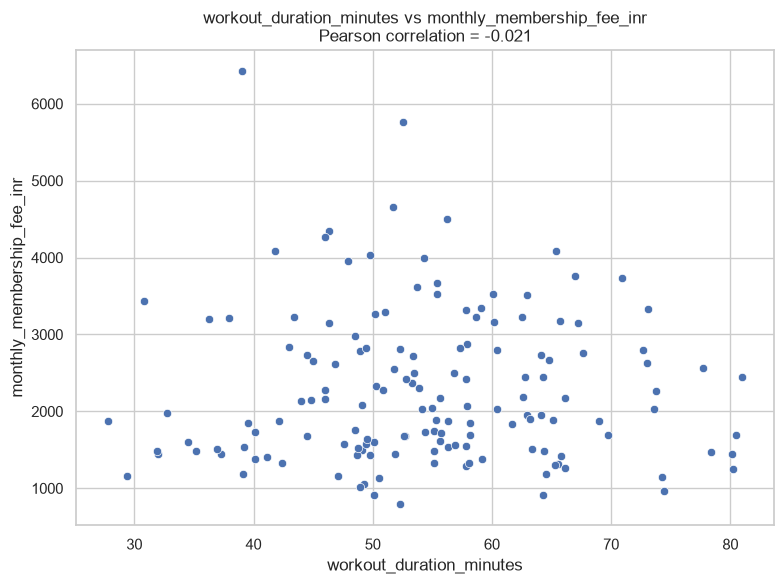

Correlation 1:
attendance_percentage vs weekly_visit_count = 0.521

Correlation 2:
workout_duration_minutes vs monthly_membership_fee_inr = -0.021


In [13]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)
# Q12 — Scatter plots and Pearson correlation

# Pair 1: hypothesized relationship
feature_x1 = "attendance_percentage"
feature_y1 = "weekly_visit_count"

corr1 = df[feature_x1].corr(df[feature_y1])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=feature_x1,
    y=feature_y1
)

plt.title(
    f"{feature_x1} vs {feature_y1}\n"
    f"Pearson correlation = {corr1:.3f}"
)

plt.xlabel(feature_x1)
plt.ylabel(feature_y1)

plt.tight_layout()
plt.show()


# Pair 2: hypothesized little/no relationship
feature_x2 = "workout_duration_minutes"
feature_y2 = "monthly_membership_fee_inr"

corr2 = df[feature_x2].corr(df[feature_y2])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=feature_x2,
    y=feature_y2
)

plt.title(
    f"{feature_x2} vs {feature_y2}\n"
    f"Pearson correlation = {corr2:.3f}"
)

plt.xlabel(feature_x2)
plt.ylabel(feature_y2)

plt.tight_layout()
plt.show()


print("Correlation 1:")
print(f"{feature_x1} vs {feature_y1} = {corr1:.3f}")

print("\nCorrelation 2:")
print(f"{feature_x2} vs {feature_y2} = {corr2:.3f}")

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [14]:
# TODO: Q13 — assemble the comparative summary table
# Q13 — Comparative summary table

summary_results = []

for feature in FEATURES:

    mean_value = df[feature].mean()
    median_value = df[feature].median()
    std_value = df[feature].std()

    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(
        df[feature],
        fisher=True
    )

    summary_results.append({
        "Feature": feature,
        "Mean": mean_value,
        "Median": median_value,
        "Standard Deviation": std_value,
        "IQR": iqr,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis
    })

summary_table = pd.DataFrame(summary_results)

display(summary_table)

,Feature,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
0,workout_duration_minutes,54.618,54.35,11.397,14.825,0.080,-0.194
1,monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.165,1.761
2,attendance_percentage,84.210,85.10,5.874,8.600,-0.556,-0.353
3,weekly_visit_count,3.337,2.40,1.886,3.500,0.441,-1.369


**Your answer (recommendation paragraph):**

_(For workout_duration_minutes, the [mean/median] and [standard deviation/IQR] are appropriate because its skewness is [value] and its spread is [value]. For monthly_membership_fee_inr, the [mean/median] and [standard deviation/IQR] are preferred because the difference between its mean and median is [small/large] and its skewness is [value]. For attendance_percentage, the [mean/median] and [standard deviation/IQR] are suitable based on its relatively [symmetric/skewed] distribution and skewness of [value]. Finally, for weekly_visit_count, the [mean/median] and [standard deviation/IQR] are recommended because its distribution shows)_

---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [17]:
# Bonus — Compare attendance percentage by workout preference

attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
    .mean()
    .sort_values(ascending=False)
)

print("Mean attendance percentage by preferred workout:")
display(attendance_by_workout)

Mean attendance percentage by preferred workout:


preferred_workout
Weights     85.526
Yoga        84.029
Cardio      83.558
CrossFit    82.325
Name: attendance_percentage, dtype: float64

---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed